In [1]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import cv2
import seaborn as sns

In [3]:
DATASET_PATH = "./dataset"
batch_size = 32
num_epochs = 50
learning_rate = 0.0001

In [ ]:
def load_dataset(dataset_path, image_size=(128, 128)):
    dataset_path = Path(dataset_path)
    class_names = sorted(path.name for path in dataset_path.iterdir() if path.is_dir())
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
    images = []
    labels = []
    for class_name in class_names:
        class_dir = dataset_path / class_name
        for image_path in sorted(class_dir.glob("*.jpg")):
            image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            # Crop the data not important
            image = image[282:1517, 70:2173]
            if image is None:
                continue
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_to_idx[class_name])
    return np.array(images), np.array(labels), np.array(class_names), class_to_idx

In [ ]:
images, labels, class_names, class_to_idx = load_dataset(DATASET_PATH)

In [6]:
print(f"Loaded {len(images)} images")
print(f"Image tensor shape: {tuple(images.shape)}")
print(f"Classes: {class_names}")

Loaded 928 images
Image tensor shape: (928, 224, 224)
Classes: ['AHB' 'HMI' 'MI' 'Normal']


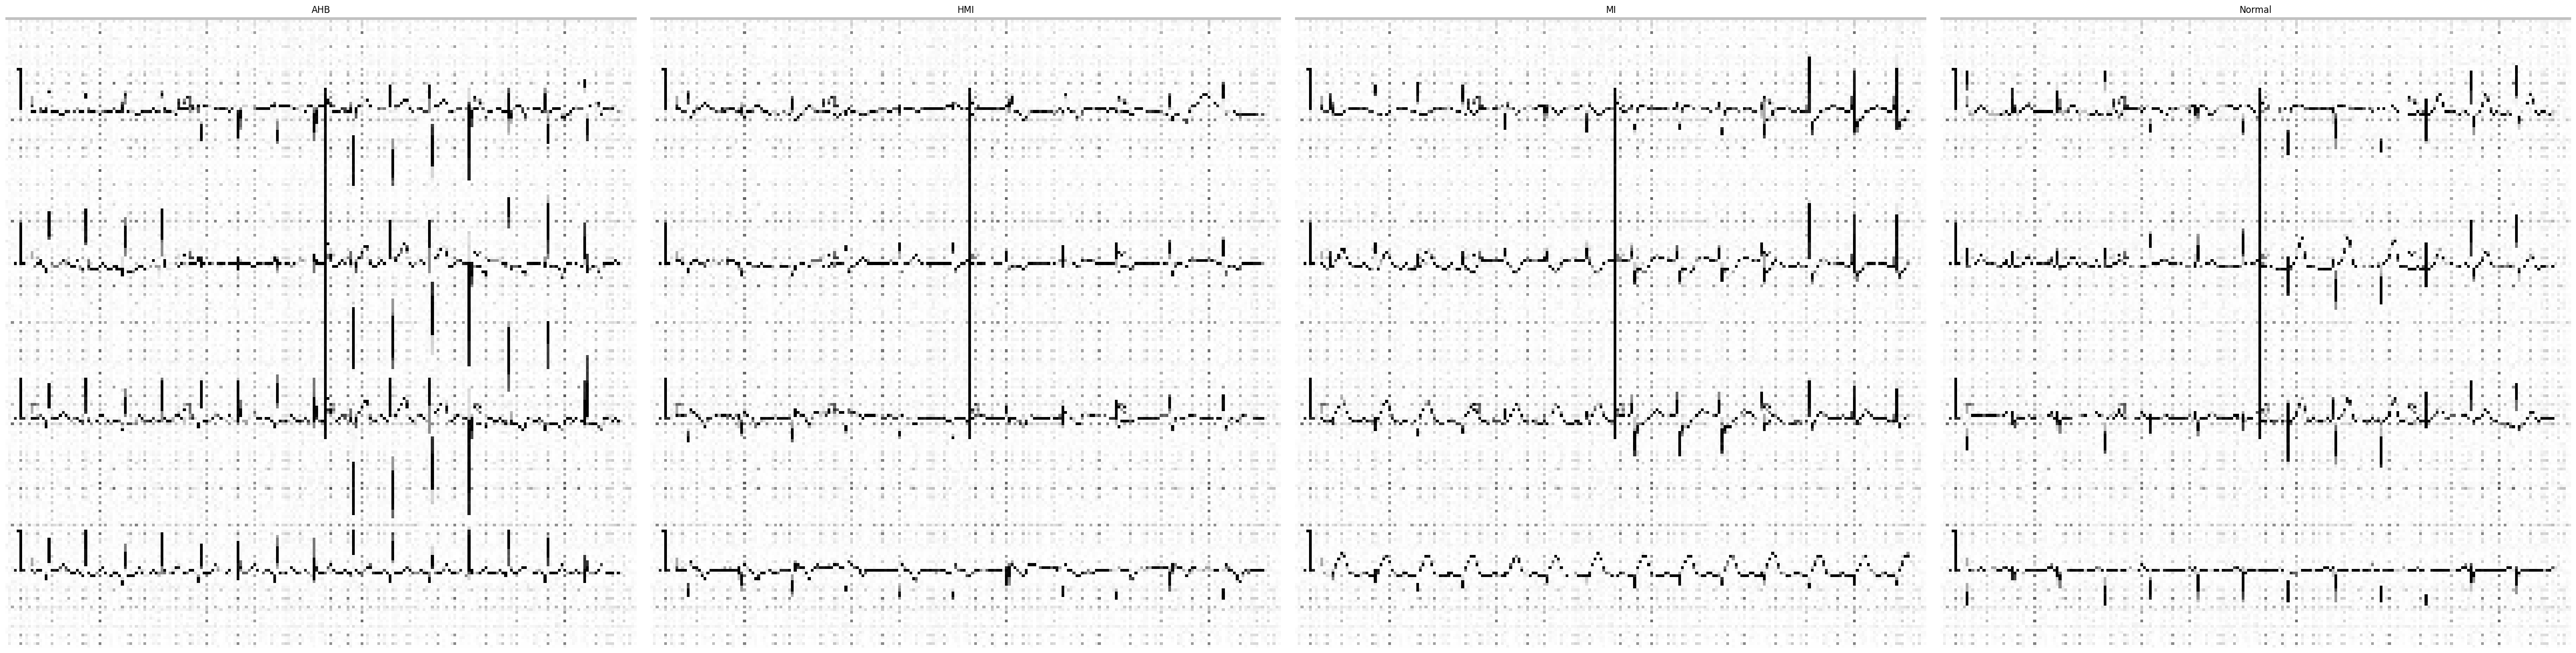

In [7]:
#Displaying sample images from each class
fig, axes = plt.subplots(1, len(class_names), figsize=(12 * len(class_names), 12))
for idx, class_name in enumerate(class_names):
    sample_index = np.where(labels == idx)[0][0]
    axes[idx].imshow(images[sample_index], cmap="gray")
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [8]:
class_counts = {class_name: int(np.sum(labels == idx)) for idx, class_name in enumerate(class_names)}
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

AHB: 233 images
HMI: 172 images
MI: 239 images
Normal: 284 images


In [9]:
# Define transforms with augmentation for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),  # Convert numpy to PIL for augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# No augmentation for validation/test
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [10]:
class ECGDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        
        if self.transform:
            sample = self.transform(sample)
        
        return sample, label

In [11]:
# Split the dataset into training, test, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [12]:
#Create dataset
train_dataset = ECGDataset(X_train, y_train, transform=train_transform)
val_dataset = ECGDataset(X_val, y_val, transform=val_transform)
test_dataset = ECGDataset(X_test, y_test, transform=val_transform)

In [13]:
# Weighted random sampler
class_sample_count = torch.tensor([(y_train == t).sum() for t in np.unique(y_train)])
weight = 1. / class_sample_count.float()
samples_weight = torch.tensor([weight[t] for t in torch.tensor(y_train)])
sampler = torch.utils.data.WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, drop_last=True)

In [14]:
val_loader = DataLoader(val_dataset, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, drop_last=False)

In [ ]:
class ConvNet(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(ConvNet, self).__init__()
        # First conv block
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        # Second conv block
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Third conv block
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout2d = nn.Dropout2d(p=0.4)
        
        # Fully connected layers
        self.fc1 = nn.Linear(256 * 16 * 16, 512)
        self.bn4 = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(512, len(class_to_idx))

    def forward(self, x):
        # Block 1: 128x128 -> 64x64
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        
        # Block 2: 64x64 -> 32x32
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)
        
        # Block 3: 32x32 -> 16x16
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.dropout2d(x)
        
        # Fully connected
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [16]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

net = ConvNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Using device: cuda


In [17]:
# Training
best_val_loss = float('inf')
patience = 10
patience_counter = 0
loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    net.train()
    epoch_loss = 0.0
    num_batches = 0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    avg_epoch_loss = epoch_loss / num_batches
    
    # VALIDATION
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data

            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    # Learning rate scheduler step
    scheduler.step(avg_val_loss)
    # Print epoch summary
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'  Training Loss:   {avg_epoch_loss:.4f}')
    print(f'  Validation Loss: {avg_val_loss:.4f}')
    print(f'  Learning Rate:   {optimizer.param_groups[0]["lr"]:.6f}')
    print('-' * 50)
    loss_history.append(avg_epoch_loss)
    val_loss_history.append(avg_val_loss)
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save(net.state_dict(), 'best_model.pth')
        print(f'  ✓ Best model saved!')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            break

print('\nFinished Training')
print(f'Best Validation Loss: {best_val_loss:.4f}')

OutOfMemoryError: CUDA out of memory. Tried to allocate 392.00 MiB. GPU 0 has a total capacity of 3.63 GiB of which 325.19 MiB is free. Including non-PyTorch memory, this process has 3.24 GiB memory in use. Of the allocated memory 3.04 GiB is allocated by PyTorch, and 121.22 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

/tmp/ipykernel_2305946/623903687.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


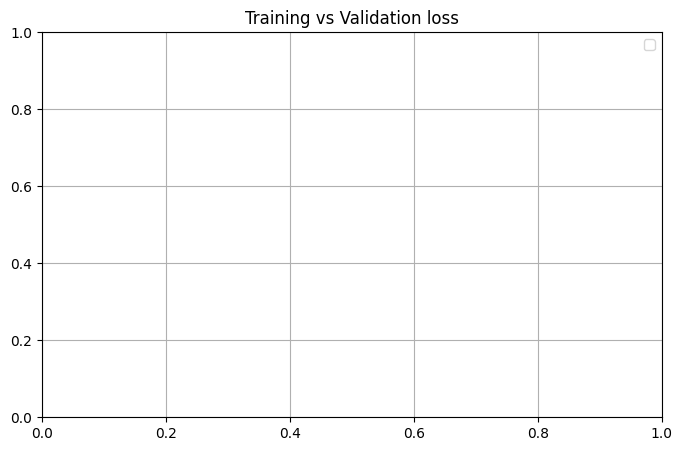

In [ ]:
# Plot losses
plot_epochs = list(range(1, len(loss_history) + 1))
plt.figure(figsize=(8,5))
sns.lineplot(x=plot_epochs, y=loss_history, marker='o', label='Train loss')
sns.lineplot(x=plot_epochs, y=val_loss_history, marker='o', label='Val loss')
plt.legend()
plt.title("Training vs Validation loss")
plt.grid(True)
plt.show()

In [32]:
# Load best model
net.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [33]:
#Evaluate on test set
net.eval()
correct = 0
total = 0
all_predictions = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 70.97%
